In [16]:
%reset -f

In [17]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
#from sklearn.cross_decomposition import CCA
from mvlearn.embed import CCA
from scipy.stats import pearsonr 
from scipy import stats


###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_processed_clara")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_fixedlag.csv")
OUT_SUBJECT = Path("subject_best_lag.csv")

SUBJECTS = np.setdiff1d(np.arange(35, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
#SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SHIFTS = np.arange(-100, 101)      # ±1 s at 100 Hz → samples
WIN_OFFSET1 = 200                  # discard first 200 ms
WIN_OFFSET2 = 110                  # discard last 110 ms

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])


In [18]:
import logging, sys
from pathlib import Path
from datetime import datetime

def start_logger(log_dir="logs", filename=None):
    Path(log_dir).mkdir(parents=True, exist_ok=True)
    if filename is None:
        filename = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

    logger = logging.getLogger("run")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()

    fh = logging.FileHandler(Path(log_dir, filename), encoding="utf-8")
    ch = logging.StreamHandler(sys.stdout)

    fmt = logging.Formatter("%(message)s")
    fh.setFormatter(fmt)
    ch.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(ch)
    logger.info(f"[log] Writing prints to: {Path(log_dir, filename)}")
    return logger

fmt="%Y%m%d_%H%M%S"
ts = datetime.now().strftime(fmt)

logger = start_logger(log_dir="logs", filename=f"sparsecca_cv_{ts}.log")

# use:
# logger.info("your message")

[log] Writing prints to: logs\sparsecca_cv_20250924_120133.log


In [19]:
# use:
logger.info("your message")

your message


In [20]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#",
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ----------------------------------------
                eeg_norm = normalise_eeg(eeg)           # your helper from before
                pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg_norm), len(pupil_z))
                eeg_norm = eeg_norm[0:T, :]  # (T × n_channels)
                pupil_z  = pupil_z[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg_norm, pupil_z, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials
    
def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials


In [21]:
import numpy as np
from typing import List, Tuple, Dict

def search_best_lag(
        train_trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shifts: np.ndarray = SHIFTS,
        return_curve: bool = False
) -> Tuple[float, int, Dict[int, float] | None]:
    """
    Search for the lag (sample shift) that maximises the mean canonical
    correlation between EEG and pupil traces in a training set.

    Parameters
    ----------
    train_trials : list of (eeg, pupil_z, meta)
        Each eeg  : 2-D array [time × channels or CCA-components]
        Each pupil: 1-D array [time]
    shifts : np.ndarray
        Array of integer lag shifts (positive = EEG is moved forward).
    return_curve : bool, default False
        If True, also return the full {shift: mean_r} dictionary.

    Returns
    -------
    best_corr : float
        Highest mean canonical correlation found.
    best_shift : int
        Shift (samples) that maximised the correlation.
    mean_r_per_shift : dict | None
        Only when `return_curve` is True.
    """
    win = slice(WIN_OFFSET1, -WIN_OFFSET2)         # common window
    mean_r_per_shift: Dict[int, float] = {}

    for s in shifts:                               # <-- loop over *shifts*, not SHIFTS
        rs = []
        for eeg, pupil_z, _ in train_trials:
            eeg_shifted = np.roll(eeg, s, axis=0)[win]
            r = cca_corr(eeg_shifted, pupil_z[win])
            rs.append(r)
        mean_r_per_shift[s] = float(np.mean(rs))   # cast to plain float for JSON-ability

    best_shift = max(mean_r_per_shift, key=mean_r_per_shift.get)
    best_corr  = mean_r_per_shift[best_shift]

    if return_curve:
        return best_corr, best_shift, mean_r_per_shift
    else:
        return best_corr, best_shift, None


In [22]:
from typing import List, Tuple, Optional
import numpy as np

def _leading_run_length_equal_first(x: np.ndarray) -> int:
    """
    Return the length of the initial run where values equal x[0].
    Works for 1D or (T,1) arrays.
    """
    x1d = x.ravel()
    if x1d.size == 0:
        return 0
    # Find first index where value != first; if none, the whole array
    neq = np.nonzero(x1d != x1d[0])[0]
    return int(neq[0]) if neq.size else int(x1d.size)


# trials  : list of (eeg, pupil_z, meta)   -- the tuples returned by load_all_trials
# shift   : integer sample shift (best_shift)
# win     : slice or None                  -- cropping window (set to None if the
#                                            trials are already pre-trimmed)
def concat_trials(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        shift: int = 0,
        win: Optional[slice] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate a list of trials into one long matrix pair ready for CCA.

    Returns
    -------
    X  : ndarray, shape (Σ Tᵢ, n_channels)
    Y  : ndarray, shape (Σ Tᵢ, 1)
    """
    X_blocks, Y_blocks = [], []

    for eeg, pupil_z, _ in trials:
        # 1. roll *inside* the trial so samples never cross trial boundaries
        eeg_shift = np.roll(eeg, shift, axis=0)

        # 2. optional windowing (do it once here if you did **not** crop in loader)
        if win is not None:
            eeg_shift = eeg_shift[win]
            pupil_seg = pupil_z[win]
        else:
            pupil_seg = pupil_z          # already trimmed earlier

        lead_len = _leading_run_length_equal_first(pupil_z)
        if lead_len > 0:
            eeg_shift = eeg_shift[lead_len:, :]
            pupil_seg = pupil_seg[lead_len:, :]
        # 3. stack
        X_blocks.append(eeg_shift)
        Y_blocks.append(pupil_seg)

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y



In [23]:
import numpy as np
rng = np.random.RandomState(42)  # reproducible shuffles

def _trial_tag(x):
    """Best-effort short tag for printing a trial object without huge dumps."""
    for attr in ("trial_id", "id", "name"):
        if hasattr(x, attr):
            return f"{attr}={getattr(x, attr)}"
    # fallback: try tuple-like or object id
    try:
        return f"tuple0={x[0]!r}"
    except Exception:
        return f"obj@{hex(id(x))}"

def _chunk_k(lst, k, rng):
    """Shuffle lst and split into k chunks (as even as possible), purely in Python."""
    idx = list(range(len(lst)))
    rng.shuffle(idx)
    shuffled = [lst[i] for i in idx]
    n = len(shuffled)
    base, rem = divmod(n, k)
    chunks, start = [], 0
    for f in range(k):
        size = base + (1 if f < rem else 0)
        chunks.append(shuffled[start:start+size])
        start += size
    return chunks

def stratified_kfold_trials(trials_memory, trials_control, k=3, verbose=False, show_examples=2):
    """
    Stratified K-fold by condition × load. Returns a list of fold dicts:
      {"train_memory", "test_memory", "train_control", "test_control"}.
    Debug prints show bucket counts, chunk sizes, per-fold sizes, and integrity checks.
    """
    # --- split memory/control by load ---
    tm05, tm09, tm13 = split_trials_by_load(trials_memory)
    tc05, tc09, tc13 = split_trials_by_load(trials_control)

    buckets = {
        ("memory", 5): list(tm05), ("memory", 9): list(tm09), ("memory", 13): list(tm13),
        ("control", 5): list(tc05), ("control", 9): list(tc09), ("control", 13): list(tc13),
    }

    order = [("memory",5),("memory",9),("memory",13),("control",5),("control",9),("control",13)]

    if verbose:
        print("\n[Bucket counts]")
        for key in order:
            print(f"  {key}: {len(buckets[key])}")

    # need at least k trials per bucket so each fold gets ≥1 in its test
    too_small = [key for key in buckets if len(buckets[key]) < k]
    if too_small:
        if verbose:
            print(f"[WARN] Not enough trials for k={k} in buckets: {too_small}. Returning [].")
        return []

    # --- split each bucket into k chunks ---
    parts = {key: _chunk_k(buckets[key], k, rng) for key in buckets}

    if verbose:
        print("\n[Chunk sizes per bucket]  (each list has k entries = fold-wise test sizes)")
        for key in order:
            sizes = [len(ch) for ch in parts[key]]
            print(f"  {key}: sizes={sizes}  total={sum(sizes)}")
            # optional: show example trial tags from first chunk
            if show_examples and len(parts[key][0]) > 0:
                ex = ", ".join(_trial_tag(t) for t in parts[key][0][:show_examples])
                print(f"      examples from fold-1 test chunk: [{ex}]")

    # --- build folds ---
    folds = []
    for f in range(k):
        test_memory  = list(parts[("memory", 5)][f]) + list(parts[("memory", 9)][f]) + list(parts[("memory", 13)][f])
        test_control = list(parts[("control", 5)][f]) + list(parts[("control", 9)][f]) + list(parts[("control", 13)][f])

        train_memory  = [x for i in range(k) if i != f for x in parts[("memory", 5)][i]] \
                      + [x for i in range(k) if i != f for x in parts[("memory", 9)][i]] \
                      + [x for i in range(k) if i != f for x in parts[("memory", 13)][i]]
        train_control = [x for i in range(k) if i != f for x in parts[("control", 5)][i]] \
                      + [x for i in range(k) if i != f for x in parts[("control", 9)][i]] \
                      + [x for i in range(k) if i != f for x in parts[("control", 13)][i]]

        folds.append({
            "train_memory":  train_memory,
            "test_memory":   test_memory,
            "train_control": train_control,
            "test_control":  test_control,
        })

    # --- per-fold debug summary ---
    if verbose:
        print("\n[Fold summaries]")
        for f, fold in enumerate(folds, 1):
            # count by load inside each set (memory/control)
            def _count_by_load(trials):
                a5, a9, a13 = split_trials_by_load(trials)
                return len(a5), len(a9), len(a13)
            tm5, tm9, tm13 = _count_by_load(fold["test_memory"])
            tc5, tc9, tc13 = _count_by_load(fold["test_control"])
            Trm5, Trm9, Trm13 = _count_by_load(fold["train_memory"])
            Trc5, Trc9, Trc13 = _count_by_load(fold["train_control"])

            print(f"  Fold {f}:")
            print(f"    TEST  mem: total={len(fold['test_memory'])}  by load: 05={tm5}, 09={tm9}, 13={tm13}")
            print(f"          ctrl: total={len(fold['test_control'])} by load: 05={tc5}, 09={tc9}, 13={tc13}")
            print(f"    TRAIN mem: total={len(fold['train_memory'])}  by load: 05={Trm5}, 09={Trm9}, 13={Trm13}")
            print(f"          ctrl: total={len(fold['train_control'])} by load: 05={Trc5}, 09={Trc9}, 13={Trc13}")

            if show_examples:
                tm_ex = ", ".join(_trial_tag(t) for t in fold["test_memory"][:show_examples])
                tc_ex = ", ".join(_trial_tag(t) for t in fold["test_control"][:show_examples])
                print(f"    examples TEST mem:  [{tm_ex}]")
                print(f"    examples TEST ctrl: [{tc_ex}]")

    # --- integrity checks (no leakage, full coverage, disjoint tests) ---
    if verbose:
        print("\n[Integrity checks]")
        # identity-based sets using id()
        all_mem_trials  = set(id(t) for t in buckets[("memory",5)] + buckets[("memory",9)] + buckets[("memory",13)])
        all_ctrl_trials = set(id(t) for t in buckets[("control",5)] + buckets[("control",9)] + buckets[("control",13)])

        # test coverage across folds
        mem_test_union  = set()
        ctrl_test_union = set()
        ok_disjoint = True
        seen_mem = set()
        seen_ctrl = set()

        for f, fold in enumerate(folds, 1):
            mem_ids  = [id(t) for t in fold["test_memory"]]
            ctrl_ids = [id(t) for t in fold["test_control"]]

            # disjointness of test sets across folds
            if mem_test_union.intersection(mem_ids) or ctrl_test_union.intersection(ctrl_ids):
                ok_disjoint = False
            mem_test_union.update(mem_ids)
            ctrl_test_union.update(ctrl_ids)

            # leakage: intersection between a fold's train and test
            leak_mem  = set(id(t) for t in fold["train_memory"]).intersection(mem_ids)
            leak_ctrl = set(id(t) for t in fold["train_control"]).intersection(ctrl_ids)
            print(f"  Fold {f} leakage mem={len(leak_mem)}  ctrl={len(leak_ctrl)}")

        print(f"  Test sets disjoint across folds? {'YES' if ok_disjoint else 'NO'}")
        print(f"  Memory test coverage {len(mem_test_union)}/{len(all_mem_trials)} "
              f"({len(mem_test_union)/max(1,len(all_mem_trials))*100:.1f}%)")
        print(f"  Control test coverage {len(ctrl_test_union)}/{len(all_ctrl_trials)} "
              f"({len(ctrl_test_union)/max(1,len(all_ctrl_trials))*100:.1f}%)")

    return folds

def stratified_kfold_trials_mem(trials_memory, k=3, verbose=False, show_examples=0):
    """
    Stratified K-fold by condition × load. Returns a list of fold dicts:
      {"train_memory", "test_memory", "train_control", "test_control"}.
    Debug prints show bucket counts, chunk sizes, per-fold sizes, and integrity checks.
    """
    # --- split memory/control by load ---
    tm05, tm09, tm13 = split_trials_by_load(trials_memory)

    buckets = {("memory", 5): list(tm05), ("memory", 9): list(tm09), ("memory", 13): list(tm13)}

    order = [("memory",5),("memory",9),("memory",13)]

    if verbose:
        print("\n[Bucket counts]")
        for key in order:
            print(f"  {key}: {len(buckets[key])}")

    # need at least k trials per bucket so each fold gets ≥1 in its test
    too_small = [key for key in buckets if len(buckets[key]) < k]
    if too_small:
        if verbose:
            print(f"[WARN] Not enough trials for k={k} in buckets: {too_small}. Returning [].")
        return []

    # --- split each bucket into k chunks ---
    parts = {key: _chunk_k(buckets[key], k, rng) for key in buckets}

    if verbose:
        print("\n[Chunk sizes per bucket]  (each list has k entries = fold-wise test sizes)")
        for key in order:
            sizes = [len(ch) for ch in parts[key]]
            print(f"  {key}: sizes={sizes}  total={sum(sizes)}")
            # optional: show example trial tags from first chunk
            if show_examples and len(parts[key][0]) > 0:
                ex = ", ".join(_trial_tag(t) for t in parts[key][0][:show_examples])
                print(f"      examples from fold-1 test chunk: [{ex}]")

    # --- build folds ---
    folds = []
    for f in range(k):
        test_memory  = list(parts[("memory", 5)][f]) + list(parts[("memory", 9)][f]) + list(parts[("memory", 13)][f])

        train_memory  = [x for i in range(k) if i != f for x in parts[("memory", 5)][i]] \
                      + [x for i in range(k) if i != f for x in parts[("memory", 9)][i]] \
                      + [x for i in range(k) if i != f for x in parts[("memory", 13)][i]]


        folds.append({
            "train_memory":  train_memory,
            "test_memory":   test_memory
        })

    # --- per-fold debug summary ---
    if verbose:
        print("\n[Fold summaries]")
        for f, fold in enumerate(folds, 1):
            # count by load inside each set (memory/control)
            def _count_by_load(trials):
                a5, a9, a13 = split_trials_by_load(trials)
                return len(a5), len(a9), len(a13)
            tm5, tm9, tm13 = _count_by_load(fold["test_memory"])
            Trm5, Trm9, Trm13 = _count_by_load(fold["train_memory"])

            print(f"  Fold {f}:")
            print(f"    TEST  mem: total={len(fold['test_memory'])}  by load: 05={tm5}, 09={tm9}, 13={tm13}")
            print(f"    TRAIN mem: total={len(fold['train_memory'])}  by load: 05={Trm5}, 09={Trm9}, 13={Trm13}")

            if show_examples:
                tm_ex = ", ".join(_trial_tag(t) for t in fold["test_memory"][:show_examples])
                print(f"    examples TEST mem:  [{tm_ex}]")

    # --- integrity checks (no leakage, full coverage, disjoint tests) ---
    if verbose:
        print("\n[Integrity checks]")
        # identity-based sets using id()
        all_mem_trials  = set(id(t) for t in buckets[("memory",5)] + buckets[("memory",9)] + buckets[("memory",13)])

        # test coverage across folds
        mem_test_union  = set()
        ok_disjoint = True
        seen_mem = set()
        seen_ctrl = set()

        for f, fold in enumerate(folds, 1):
            mem_ids  = [id(t) for t in fold["test_memory"]]

            # disjointness of test sets across folds
            if mem_test_union.intersection(mem_ids):
                ok_disjoint = False
            mem_test_union.update(mem_ids)

            # leakage: intersection between a fold's train and test
            leak_mem  = set(id(t) for t in fold["train_memory"]).intersection(mem_ids)
            print(f"  Fold {f} leakage mem={len(leak_mem)}")

        print(f"  Test sets disjoint across folds? {'YES' if ok_disjoint else 'NO'}")
        print(f"  Memory test coverage {len(mem_test_union)}/{len(all_mem_trials)} "
              f"({len(mem_test_union)/max(1,len(all_mem_trials))*100:.1f}%)")

    return folds

### training on mem, lets make a sample inner loop to determine optimal lag and l1 regularisation parameter per subject and see how much we can raise the correlation in memory

In [24]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from cca_zoo.linear import SCCA_IPLS, ElasticCCA, SCCA_Parkhomenko, SCCA_Span
from cca_zoo.model_selection import GridSearchCV   # optional, if you use their CV helper

def candidate_lags_units(step_ms=100, max_ms=1000):
    # Your code uses 10 ms units (lag_ms = shift*10)
    step_units = step_ms // 10
    max_units  = max_ms  // 10
    return list(range(-max_units, max_units + 1, step_units))

def concat_for_trials(trials, shift_units, win):
    X, Y = concat_trials(trials, shift=shift_units, win=win)
    return X, Y

def val_score_ElCCA(Xtr, Ytr, Xva, Yva, alpha_x):
    sx = StandardScaler().fit(Xtr)
    #sy = StandardScaler().fit(Ytr)
    Xtr_s, Ytr_s = sx.transform(Xtr), Ytr
    Xva_s, Yva_s = sx.transform(Xva), Yva
    # L1 on X only, no penalty on Y (1D pupil)
    model = ElasticCCA(
        latent_dimensions=1,
        alpha=[alpha_x, 0.0],      # tune alpha_x; 0.0 for pupil
        l1_ratio=[1.0, 0.0],       # pure L1 on X; none on Y
        random_state=42,
        verbose=False
    )

    model.fit((Xtr_s, Ytr_s))
    zx, zy = model.transform((Xva_s, Yva_s))
    r, p = pearsonr(zx[:, 0], zy[:, 0])
    logger.info(f"  val r={r:.4f} (p={p:.3g}) with alpha_x={alpha_x}")
    return r


In [25]:
from math import atanh, tanh
def pick_subject_hyperparams_memory_only(trials_memory, win,
                                         lags_units=None,
                                         alpha_grid=None,
                                         k_inner=3,
                                         min_len=50,
                                         seed=42):
    """
    One loop: K-fold CV within this subject's MEMORY trials only.
    Returns (best_lag_units, best_tau_x).

    NEED TO FIX, look at the look I actually wrote!!!
    """
    if lags_units is None:
        lags_units = candidate_lags_units(step_ms=100, max_ms=1000)  # ±1 s, 100 ms steps
    if alpha_grid is None:
        alpha_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2] # adjust if too sparse/dense

    folds = stratified_kfold_trials_mem(trials_memory, k=K)

    best = {"score": -np.inf, "lag_u": 0, "alpha_x": alpha_grid[0]}

    for lag_u in lags_units:
        for fold in folds:
            tr_trials = fold["train_memory"]
            va_trials = fold["test_memory"]

            Xtr, Ytr = concat_for_trials(tr_trials, shift_units=lag_u, win=win)
            Xva, Yva = concat_for_trials(va_trials,   shift_units=lag_u, win=win)
            if len(Xtr) < min_len or len(Xva) < min_len:
                continue

            for alpha_x in alpha_grid:
                r = val_score_ElCCA(Xtr, Ytr, Xva, Yva, alpha_x)
                if r > best["score"]:
                    best.update({"score": r, "lag_u": lag_u, "alpha_x": alpha_x})

    return best["lag_u"], best["alpha_x"]

def fisher_mean(rs):
    rs = np.clip(rs, -0.999999, 0.999999)
    return tanh(np.mean([atanh(r) for r in rs]))


In [26]:
from pathlib import Path
import json, numpy as np, pandas as pd

def _get_weights_any(model):
    """
    Returns (W_X, W_Y) as 2D arrays (n_feat_x, d), (n_feat_y, d).
    Supports sklearn CCA and CCA-Zoo (ElasticCCA, SCCA_IPLS, etc.).
    """
    # CCA-Zoo style
    W = getattr(model, "weights_", None)
    if W is not None:
        W_X, W_Y = W
        W_X = np.asarray(W_X)
        W_Y = np.asarray(W_Y)
        if W_X.ndim == 1: W_X = W_X[:, None]
        if W_Y.ndim == 1: W_Y = W_Y[:, None]
        return W_X, W_Y

    # sklearn style
    if hasattr(model, "x_weights_") and hasattr(model, "y_weights_"):
        W_X = np.asarray(model.x_weights_)
        W_Y = np.asarray(model.y_weights_)
        if W_X.ndim == 1: W_X = W_X[:, None]
        if W_Y.ndim == 1: W_Y = W_Y[:, None]
        return W_X, W_Y

    raise AttributeError("Model has no weights_ / x_weights_ / y_weights_ attributes.")

def save_cca_weights_any(model, subject_tag, lag_ms, eeg_ch_names, condition, out_dir=Path("weights"), x_scaler = None):
    """
    Save EEG & pupil canonical weights for models from sklearn or CCA-Zoo.
    Normalizes so pupil weight for the first canonical dim is 1.0 when Y is 1-D.
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    W_X, W_Y = _get_weights_any(model)  # (nX,d), (nY,d)
    # first canonical dimension
    w_eeg = W_X[:, 0].astype(float)
    w_pup_vec = W_Y[:, 0].astype(float)

    # --- back-transform to original scales (only divides by std; centering irrelevant) ---
    if x_scaler is not None and hasattr(x_scaler, "scale_"):
        w_eeg_orig = w_eeg / x_scaler.scale_
    else:
        print("  [warn] No x_scaler provided, saving weights on standardized scale")
        w_eeg_orig = w_eeg.copy()

    # If pupil is 1-D, scale so its weight becomes 1.0
    if w_pup_vec.size == 1:
        w_pupil_orig = float(w_pup_vec[0])
        scale = 1.0 / w_pupil_orig if w_pupil_orig != 0 else 1.0
        w_pupil = 1.0
        w_eeg_final = w_eeg_orig * scale
        # save pupil weight JSON
        with open(out_dir / f"{subject_tag}_pupil_weight_{condition}_{lag_ms:+d}ms.json", "w") as fh:
            json.dump({"weight": w_pupil, "original_weight": w_pupil_orig}, fh, indent=2)
    else:
        # multi-dim pupil: just dump the vector (no normalization)
        print("  [warn] Multi-dimensional pupil weights, not normalizing to 1.0")
        with open(out_dir / f"{subject_tag}_pupil_weights_{condition}_{lag_ms:+d}ms.json", "w") as fh:
            json.dump({"weights": w_pup_vec.tolist()}, fh, indent=2)

    # save EEG weights CSV (tidy)
    w_eeg_series = pd.Series(w_eeg_final, index=eeg_ch_names, name="weight")
    w_eeg_series.index.name = "channel"
    w_eeg_series.to_csv(out_dir / f"{subject_tag}_eeg_weights_{condition}_{lag_ms:+d}ms.csv") # weight_pupil = 1.0

    w_eeg_series_orig = pd.Series(w_eeg_orig, index=eeg_ch_names, name="weight_standardized")
    w_eeg_series_orig.index.name = "channel"
    w_eeg_series_orig.to_csv(out_dir / f"{subject_tag}_eeg_weights_std_{condition}_{lag_ms:+d}ms.csv")

    print(f"saved weights for {subject_tag} (lag {lag_ms:+d} ms) → {out_dir}")

# usage (after fitting ElasticCCA / SCCA_IPLS):
# save_cca_weights_any(best_model, f"sub-{subj:03d}", best_lag_ms, FRONTAL_MIDLINE, f"mem_fold{fold_idx}", Path("weights_loopReg"))


In [ ]:
import random
from math import atanh, sqrt
from scipy.stats import norm, ttest_rel, wilcoxon

import matplotlib.pyplot as plt

K = 3
all_rows = []  # collect all trial-level results here
# best_shift_by_sub = {}  # best shift per subject
rows_trials = []
rows_subject = []
rows_folds   = []   # per-fold diagnostics  
bad_subjects_mem = []
bad_subjects_ctrl = []

for subj in SUBJECTS:
    if subj == 57:
        continue
    logger.info(f"Processing subject {subj:02d}...")
    trials = load_all_trials(subj)                         # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(trials)

    random.shuffle(trials_memory)
    random.shuffle(trials_control)

    # --- pick (lag, alpha_x) ONCE for this subject using only memory trials ---
    lags_units = candidate_lags_units(step_ms=100, max_ms=1000)   # or tighten if slow
    alpha_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2] 
    win = slice(WIN_OFFSET1, -WIN_OFFSET2) 

    #best_lag_units, best_alpha_x = pick_subject_hyperparams_memory_only(
    #    trials_memory=trials_memory,
    #    win=win,
    #    lags_units=lags_units,
    #    alpha_grid=alpha_grid,
    #    k_inner=3,
    #    min_len=50,
    #    seed=42
    #)

    lags_units = candidate_lags_units(step_ms=100, max_ms=1000)  # ±1 s, 100 ms steps
    alpha_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2] # adjust if too sparse/dense
    min_len = 50

    folds = stratified_kfold_trials_mem(trials_memory, k=K)

    best = {"score": -np.inf, "lag_u": None, "alpha_x": None}

    for lag_u in lags_units:
        logger.info(f" Testing lag {lag_u*10:+d} ms...")
        for alpha_x in alpha_grid:
            logger.info(f"  Trying alpha_x={alpha_x}...")
            fold_rs = []
            i = 0
            for fold in folds:
                logger.info(f"   Fold {i+1}/{len(folds)}...")
                tr_trials = fold["train_memory"]
                va_trials = fold["test_memory"]

                Xtr, Ytr = concat_for_trials(tr_trials, shift_units=lag_u, win=win)
                Xva, Yva = concat_for_trials(va_trials,   shift_units=lag_u, win=win)
                if len(Xtr) < min_len or len(Xva) < min_len:
                    continue

                r = val_score_ElCCA(Xtr, Ytr, Xva, Yva, alpha_x)  # returns Pearson r on val
                if np.isfinite(r):
                    fold_rs.append(r)
                
                i += 1

            if len(fold_rs) == 0:
                logger.info(f"   [warn] No valid folds for subject {subj:02d} lag {lag_u*10:+d} ms, alpha_x={alpha_x}. Skipping.")
                continue

            # Aggregate across folds (Fisher-z mean is standard)
            mean_r = fisher_mean(fold_rs)

            if mean_r > best["score"]:
                best.update({"score": mean_r, "lag_u": lag_u, "alpha_x": alpha_x})

    best_lag_units, best_alpha_x = best["lag_u"], best["alpha_x"]

    if best_lag_units is None or best_alpha_x is None:
        logger.info(f"   [warn] No valid (lag, alpha_x) found for subject {subj:02d}. Skipping.")
        bad_subjects_mem.append(subj)
        continue

    best_lag_ms = int(best_lag_units * 10)
    logger.info(f"Subject {subj:02d}: chosen lag={best_lag_ms:+d} ms, alpha_x={best_alpha_x:g} (mean r={best['score']:.3f})")

    # Fit sparse CCA once on outer-train memory (using chosen alpha_x)
    X_mem, Y_mem = concat_trials(trials_memory, shift=best_lag_units, win=win)
    X_ctl, Y_ctl = concat_trials(trials_control, shift=best_lag_units, win=win)

    sx = StandardScaler().fit(X_mem)
    X_mem_s, Y_mem_s = sx.transform(X_mem), Y_mem
    X_ctl_s, Y_ctl_s = sx.transform(X_ctl), Y_ctl

    first = True
    while True:
        best_model = ElasticCCA(
            latent_dimensions=1,
            alpha=[best_alpha_x, 0.0],      # tune alpha_x; 0.0 for pupil
            l1_ratio=[1, 0.0],       # pure L1 on X; none on Y
            random_state=42,
            verbose=False
        )

        best_model.fit((X_mem_s, Y_mem_s))

        if np.linalg.norm(best_model.weights_[0]) > 0:
            if not first:
                logger.info(f"Alpha {best_alpha_x} gives non-zero weights")
            break
        logger.info("Refitting due to zero weights...")
        best_alpha_x *= 0.9
        first = False

    # Evaluate on all memory and control
    cvX_m, cvY_m = best_model.transform((X_mem_s, Y_mem_s))
    r_mem, p_mem = pearsonr(cvX_m[:, 0], cvY_m[:, 0])

    cvX_c, cvY_c = best_model.transform((X_ctl_s, Y_ctl_s))
    r_ctrl, p_ctrl = pearsonr(cvX_c[:, 0], cvY_c[:, 0])
    
    rows_subject.append({ 
        "subject": subj, 
        "condition": "memory", 
        "lag_ms": best_lag_ms,
        "alpha_x": best_alpha_x, 
        "r": float(r_mem),
        "p-value": float(p_mem)
    })

    rows_subject.append({ 
        "subject": subj, 
        "condition": "control", 
        "lag_ms": best_lag_ms, 
        "alpha_x": best_alpha_x,
        "r": float(r_ctrl),
        "p-value": float(p_ctrl)
    })

    # Save EEG weights (sparse scalp map)
    wx = getattr(best_model, "weights_", getattr(best_model, "weights", None))[0].ravel()

    save_cca_weights_any(best_model, f"sub-{subj:03d}", best_lag_ms, FRONTAL_MIDLINE, "mem", Path(f"CCAReg/weights_{ts}_"), x_scaler=sx)

    pd.DataFrame(rows_subject).to_csv(f"CCAReg/subject_level_cca_{ts}.csv", index=False)

pd.DataFrame(rows_subject).to_csv(f"CCAReg/subject_level_cca.csv_{ts}.csv", index=False)




Processing subject 35...
 Testing lag -1000 ms...
  Trying alpha_x=0.0001...
   [warn] No valid folds for subject 35 lag -1000 ms, alpha_x=0.0001. Skipping.
  Trying alpha_x=0.0003...
   [warn] No valid folds for subject 35 lag -1000 ms, alpha_x=0.0003. Skipping.
  Trying alpha_x=0.001...
   [warn] No valid folds for subject 35 lag -1000 ms, alpha_x=0.001. Skipping.
  Trying alpha_x=0.003...
   [warn] No valid folds for subject 35 lag -1000 ms, alpha_x=0.003. Skipping.
  Trying alpha_x=0.01...
   [warn] No valid folds for subject 35 lag -1000 ms, alpha_x=0.01. Skipping.
 Testing lag -900 ms...
  Trying alpha_x=0.0001...
   [warn] No valid folds for subject 35 lag -900 ms, alpha_x=0.0001. Skipping.
  Trying alpha_x=0.0003...
   [warn] No valid folds for subject 35 lag -900 ms, alpha_x=0.0003. Skipping.
  Trying alpha_x=0.001...
   [warn] No valid folds for subject 35 lag -900 ms, alpha_x=0.001. Skipping.
  Trying alpha_x=0.003...
   [warn] No valid folds for subject 35 lag -900 ms, alph

Latent Dimension: 100%|██████████| 1/1 [00:00<00:00,  1.70it/s]

  val r=-0.0232 (p=6.47e-05) with alpha_x=0.0001
   Fold 2/3...



Latent Dimension: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]

  val r=-0.0102 (p=0.109) with alpha_x=0.0001
   Fold 3/3...


...


Latent Dimension: 100%|██████████| 1/1 [00:00<00:00,  3.43it/s]

  val r=nan (p=nan) with alpha_x=0.001
   Fold 2/3...



C:\Users\cdd\AppData\Local\Temp\ipykernel_20148\3107632715.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(zx[:, 0], zy[:, 0])
Latent Dimension: 100%|██████████| 1/1 [00:00<00:00,  4.00it/s]

  val r=nan (p=nan) with alpha_x=0.001
   Fold 3/3...



C:\Users\cdd\AppData\Local\Temp\ipykernel_20148\3107632715.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(zx[:, 0], zy[:, 0])


In [ ]:
import pandas as pd
import glob
from pathlib import Path

# >>> change nothing below unless you need to tweak <<<
ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\CCAReg\elastic_weights2")

# Match: sub-xxx_eeg_weights_mem_....csv  (xxx and the trailing part can be anything)
pattern = str(ROOT / r"sub-*_eeg_weights_mem_*.csv")  # note: double underscore only if your files have it
# If your files actually use a single underscore, use this instead:
# pattern = str(ROOT / r"sub-*_eeg_weights_mem_*.csv")

files = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No files matched pattern:\n{pattern}\n"
                            "If your files have a different underscore pattern, switch the pattern line.")

dfs = []
for fp in files:
    df = pd.read_csv(fp)
    # normalize column names just in case
    df.columns = [c.strip().lower() for c in df.columns]
    if not {"channel", "weight"} <= set(df.columns):
        raise ValueError(f"{fp} is missing required columns 'channel' and 'weight'")
    # keep only what's needed
    dfs.append(df[["channel", "weight"]].copy())

all_weights = pd.concat(dfs, ignore_index=True)

summary = (
    all_weights
    .groupby("channel", as_index=True)["weight"]
    .agg(mean="mean", std="std", count="count")
    .sort_index()
)

out_path = ROOT / "avg_eeg_weights_mem.csv"
summary.to_csv(out_path)

print(f"Read {len(files)} files.")
print(f"Saved per-electrode summary to: {out_path}")
print(summary.head(10))


Saved scalp map to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\CCAReg\elastic_weights2\avg_eeg_weights_mem_topomap.png


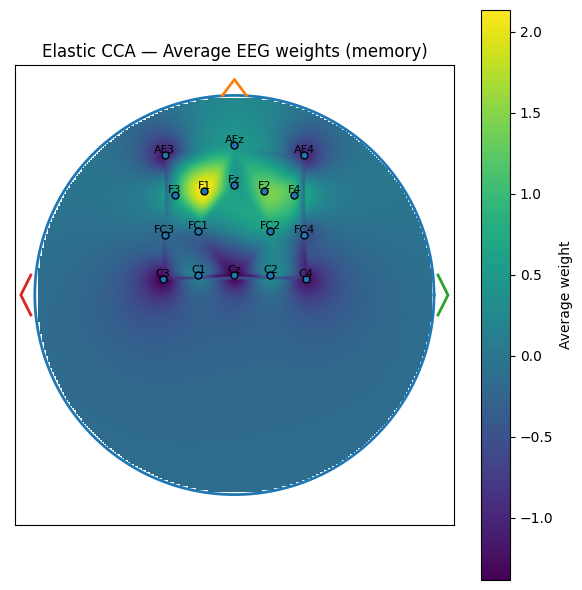

In [13]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Try to use SciPy's griddata for smooth interpolation; fallback to IDW if unavailable.
try:
    from scipy.interpolate import griddata
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# --- Configuration ---
CSV_PATH = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\CCAReg\elastic_weights2\avg_eeg_weights_mem.csv")
OUT_PATH = CSV_PATH.with_name("avg_eeg_weights_mem_topomap.png")

# Approximate 10–20 2D coordinates on a unit head (front = +y, left = -x)
# These are schematic positions good enough for qualitative topomaps.
POS = {
    "AFz": (0.0,  0.75),
    "AF3": (-0.35, 0.70),
    "AF4": ( 0.35, 0.70),

    "Fz":  (0.0,  0.55),
    "F1":  (-0.15, 0.52),
    "F2":  ( 0.15, 0.52),
    "F3":  (-0.30, 0.50),
    "F4":  ( 0.30, 0.50),

    "FC1": (-0.18, 0.32),
    "FC2": ( 0.18, 0.32),
    "FC3": (-0.35, 0.30),
    "FC4": ( 0.35, 0.30),

    "Cz":  (0.0,  0.10),
    "C1":  (-0.18, 0.10),
    "C2":  ( 0.18, 0.10),
    "C3":  (-0.36, 0.08),
    "C4":  ( 0.36, 0.08),

    # (Add more labels here if present in your CSVs)
}

# --- Load CSV (expects columns: channel, weight) ---
names, vals = [], []
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    weight_col = "mean"

    # read rows
    for row in reader:
        ch = (row.get("channel")).strip()
        if not ch:
            continue
        try:
            w = float(row.get(weight_col))
        except Exception:
            # row might have original casing; try more robustly
            w = float(row[[k for k in row if k.lower() == weight_col][0]])
        if ch in POS:
            names.append(ch)
            vals.append(w)

if not names:
    raise RuntimeError("No channels from the CSV matched the known scalp positions in POS. "
                       "Add the missing labels to POS.")

xy = np.array([POS[ch] for ch in names])
z = np.array(vals, dtype=float)

mu = z.mean()
sd = z.std(ddof=0)
if sd == 0:
    z = np.zeros_like(z)  # all equal -> all zeros after standardization
else:
    z = (z - mu) / sd

# --- Build grid on the unit head circle ---
N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0  # inside head

# --- Interpolate to grid ---
def idw_interpolate(points, values, gx, gy, power=2.0, eps=1e-12):
    """Inverse-distance weighting as a fallback (no SciPy)."""
    px = points[:, 0][:, None, None]
    py = points[:, 1][:, None, None]
    dx = gx[None, :, :] - px
    dy = gy[None, :, :] - py
    d2 = dx*dx + dy*dy
    w = 1.0 / (d2 + eps)**(power/2)
    num = (w * values[:, None, None]).sum(axis=0)
    den = w.sum(axis=0)
    return num / (den + eps)

if _HAS_SCIPY:
    GZ = griddata(xy, z, (GX, GY), method="cubic")
    # fill NaNs (outside convex hull) via IDW to avoid holes at edges
    nan_mask = np.isnan(GZ)
    if nan_mask.any():
        GZ_idw = idw_interpolate(xy, z, GX, GY, power=2.0)
        GZ[nan_mask] = GZ_idw[nan_mask]
else:
    GZ = idw_interpolate(xy, z, GX, GY, power=2.0)

# mask outside head
GZ_masked = np.ma.array(GZ, mask=~mask)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    GZ_masked,
    origin="lower",
    extent=(-1, 1, -1, 1),
    interpolation="bilinear",
)
# head outline
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), linewidth=2)

# simple nose
nose_x = np.array([ -0.06, 0.0, 0.06 ])
nose_y = np.array([  1.00, 1.08, 1.00 ])
ax.plot(nose_x, nose_y, linewidth=2)

# ears
ear_x = np.array([1.02, 1.07, 1.02])
ear_y = np.array([ 0.10, 0.00, -0.10])
ax.plot( ear_x,  ear_y, linewidth=2)
ax.plot(-ear_x,  ear_y, linewidth=2)

# electrodes as dots
ex, ey = xy[:, 0], xy[:, 1]
ax.scatter(ex, ey, s=25, edgecolors="k")
for ch, (cx, cy) in POS.items():
    if ch in names:
        ax.text(cx, cy, ch, ha="center", va="bottom", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Average weight")

ax.set_aspect("equal")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.15, 1.15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Elastic CCA — Average EEG weights (memory)")

fig.tight_layout()
fig.savefig(OUT_PATH, dpi=200)
print(f"Saved scalp map to: {OUT_PATH}")
plt.show()
